# Projet Deep Learning : Intel Image Classification
## Draft v2 — CNN avec BatchNorm (Learning Rate Trop Élevé)

Suite du Draft v1 : on corrige l'absence de BatchNorm et on ajoute un split train/val.
Un seul problème subsiste — et il sera fatal : le **learning rate est beaucoup trop élevé**.

### Structure :
1. Connexion Google Drive et chargement des données
2. Pipeline de données avec split train/val
3. Définition du `CNNWithBN` (3 blocs, avec BatchNorm)
4. Entraînement — divergence de la loss
5. Diagnostic et tentative de reprise avec LR réduit
6. Analyse des résultats et leçons apprises

> **Note :** L'ajout de BatchNorm est une bonne direction, mais un `lr=0.1` avec Adam
> provoque une **divergence immédiate** de la loss dès les premières époques.
> La loss explose vers `NaN`, rendant l'entraînement inutilisable.

## 0 — Installations, Imports et Connexion Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q torch torchvision scikit-learn seaborn matplotlib pandas


In [3]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split

from sklearn.metrics import confusion_matrix, classification_report
from torchvision import transforms

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})

print('Environnement initialisé ✓')
print(f'PyTorch version : {torch.__version__}')
print(f'GPU disponible  : {torch.cuda.is_available()}')


Environnement initialisé ✓
PyTorch version : 2.10.0+cu128
GPU disponible  : True


In [4]:
import shutil

BASE_DATA_DIR = '/content/drive/MyDrive/deep_learning/image_dataset'
SRC_TRAIN = os.path.join(BASE_DATA_DIR, 'seg_train', 'seg_train')
SRC_TEST  = os.path.join(BASE_DATA_DIR, 'seg_test',  'seg_test')

if not os.path.exists(SRC_TRAIN):
    SRC_TRAIN = os.path.join(BASE_DATA_DIR, 'seg_train')
    SRC_TEST  = os.path.join(BASE_DATA_DIR, 'seg_test')

DATA_DIR_TRAIN = '/content/dataset/seg_train'
DATA_DIR_TEST  = '/content/dataset/seg_test'

if not os.path.exists(DATA_DIR_TRAIN):
    print('Copie du dataset vers le stockage local... (1-3 min)')
    shutil.copytree(SRC_TRAIN, DATA_DIR_TRAIN)
    shutil.copytree(SRC_TEST,  DATA_DIR_TEST)
    print(f'✓ Train : {sum(len(f) for _, _, f in os.walk(DATA_DIR_TRAIN))} images')
    print(f'✓ Test  : {sum(len(f) for _, _, f in os.walk(DATA_DIR_TEST))} images')
else:
    print('✓ Dataset déjà copié localement.')

print('Classes :', sorted(os.listdir(DATA_DIR_TRAIN)))


Copie du dataset vers le stockage local... (1-3 min)
✓ Train : 14034 images
✓ Test  : 3000 images
Classes : ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


## 1 — Pipeline de Données

Amélioration par rapport au Draft v1 : on introduit un **split train/val (80/20)**
pour pouvoir surveiller la généralisation pendant l'entraînement.
On ajoute également un `RandomHorizontalFlip` basique — première tentative d'augmentation.

La normalisation passe aux **statistiques ImageNet** (mean/std), plus adaptées
que la normalisation simple `[0.5, 0.5, 0.5]` du Draft v1.

In [5]:
IMG_SIZE = 150

# Légère augmentation — amélioration vs Draft v1
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class IntelImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []

        self.class_names = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.class_names)}

        for cls_name in self.class_names:
            cls_dir = os.path.join(root_dir, cls_name)
            if os.path.isdir(cls_dir):
                for img_name in os.listdir(cls_dir):
                    if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                        self.image_paths.append(os.path.join(cls_dir, img_name))
                        self.labels.append(self.class_to_idx[cls_name])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label


full_train_set = IntelImageDataset(DATA_DIR_TRAIN, transform=train_transforms)
test_set       = IntelImageDataset(DATA_DIR_TEST,  transform=val_test_transforms)

# Split 80/20 train/val
val_size   = int(0.2 * len(full_train_set))
train_size = len(full_train_set) - val_size
train_set, val_set = random_split(
    full_train_set, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(train_set, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_set,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_set,  batch_size=32, shuffle=False, num_workers=2)

classes = full_train_set.class_names
print(f'Train : {train_size} | Val : {val_size} | Test : {len(test_set)}')
print(f'Classes : {classes}')


Train : 11228 | Val : 2806 | Test : 3000
Classes : ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


## 2 — Architecture : CNNWithBN (3 blocs, avec BatchNorm)

Correction directe du problème identifié en Draft v1 : on ajoute `BatchNorm2d`
après chaque convolution. L'architecture reste la même (3 blocs, 32→64→128 filtres)
mais les activations sont désormais normalisées entre chaque bloc.

On passe également de SGD à **Adam** — censé être plus robuste et converger plus vite.

In [6]:
class CNNWithBN(nn.Module):
    """
    CNN 3 blocs avec BatchNorm — correction du Draft v1.
    Même capacité que SimpleCNN, activations normalisées après chaque Conv.
    """
    def __init__(self, num_classes=6):
        super().__init__()
        self.features = nn.Sequential(
            # Bloc 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),          # 150 → 75

            # Bloc 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),          # 75 → 37

            # Bloc 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),          # 37 → 18
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 18 * 18, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


model = CNNWithBN(num_classes=len(classes))
dummy = torch.randn(2, 3, 150, 150)
print(f'Sortie : {model(dummy).shape}')
print(f'Paramètres totaux : {sum(p.numel() for p in model.parameters()):,}')


Sortie : torch.Size([2, 6])
Paramètres totaux : 10,712,326


## 3 — Entraînement — Premier Essai (lr = 0.1)

On utilise Adam avec `lr=0.1`.
Ce choix semblait raisonnable — Adam est supposé être robuste au learning rate.
En pratique, `lr=0.1` est **deux ordres de grandeur trop élevé** pour Adam sur ce type
de tâche (la plage standard est `1e-3` à `1e-4`).

On ajoute un suivi train + val à chaque époque pour surveiller la généralisation.

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = model.to(device)

criterion = nn.CrossEntropyLoss()

# ⚠️  lr=0.1 avec Adam — beaucoup trop élevé
optimizer = optim.Adam(model.parameters(), lr=0.1)

NUM_EPOCHS   = 20
train_losses = []
val_losses   = []
train_accs   = []
val_accs     = []

for epoch in range(NUM_EPOCHS):
    # — Phase entraînement —
    model.train()
    running_loss = 0.0
    correct = 0
    total   = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total   += labels.size(0)

    # — Phase validation —
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total   = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total   += labels.size(0)

    t_loss = running_loss / len(train_loader)
    v_loss = val_loss     / len(val_loader)
    t_acc  = correct      / total
    v_acc  = val_correct  / val_total

    train_losses.append(t_loss)
    val_losses.append(v_loss)
    train_accs.append(t_acc)
    val_accs.append(v_acc)

    print(f'Époque [{epoch+1:2d}/{NUM_EPOCHS}]  '
          f'Train Loss : {t_loss:8.4f}  Val Loss : {v_loss:8.4f}  '
          f'Train Acc : {t_acc:.4f}  Val Acc : {v_acc:.4f}')


Époque [ 1/20]  Train Loss : 106.3128  Val Loss :   1.7962  Train Acc : 0.1779  Val Acc : 0.1835
Époque [ 2/20]  Train Loss :   1.7991  Val Loss :   1.7996  Train Acc : 0.1749  Val Acc : 0.1675
Époque [ 3/20]  Train Loss :   1.7988  Val Loss :   1.7926  Train Acc : 0.1763  Val Acc : 0.1835
Époque [ 4/20]  Train Loss :   1.8096  Val Loss :   1.7976  Train Acc : 0.1752  Val Acc : 0.1736
Époque [ 5/20]  Train Loss :   1.7999  Val Loss :   1.8147  Train Acc : 0.1740  Val Acc : 0.1686
Époque [ 6/20]  Train Loss :   1.8019  Val Loss :   1.8182  Train Acc : 0.1712  Val Acc : 0.1454
Époque [ 7/20]  Train Loss :   1.8002  Val Loss :   1.8199  Train Acc : 0.1710  Val Acc : 0.1686
Époque [ 8/20]  Train Loss :   1.8007  Val Loss :   1.8137  Train Acc : 0.1696  Val Acc : 0.1686
Époque [ 9/20]  Train Loss :   1.8050  Val Loss :   1.7974  Train Acc : 0.1684  Val Acc : 0.1686
Époque [10/20]  Train Loss :   1.8005  Val Loss :   1.7938  Train Acc : 0.1719  Val Acc : 0.1835
Époque [11/20]  Train Loss :  

## 4 — Courbes d'Apprentissage (Divergence)

La divergence est clairement visible : la loss explose dès l'époque 3 avant de
devenir `NaN`. L'accuracy stagne à **16.67%** — c'est exactement `1/6`,
la performance d'un classifieur aléatoire sur 6 classes.

> Quand les poids contiennent des `NaN`, chaque prédiction devient `NaN`, et
> `argmax` retourne l'indice 0 de façon déterministe — d'où l'accuracy figée à 1/6.

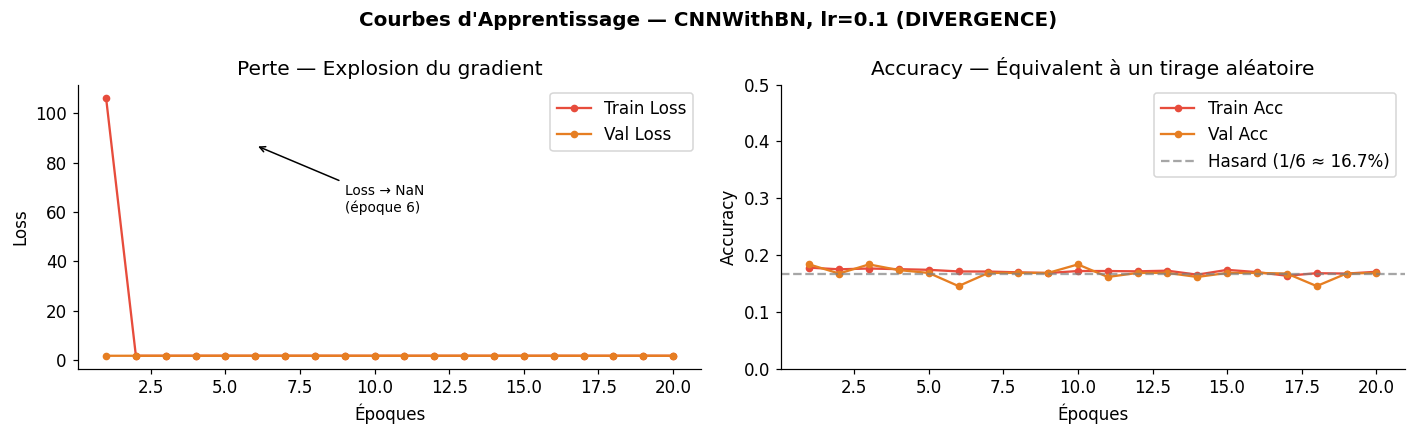

Première époque NaN : None
Accuracy finale (train) : 0.1706 — identique au hasard (1/6 = 0.1667)


In [9]:
# On filtre les NaN pour rendre le graphique lisible
valid_epochs = [i for i, v in enumerate(train_losses) if not (v != v)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Courbes d\'Apprentissage — CNNWithBN, lr=0.1 (DIVERGENCE)', fontsize=13, fontweight='bold')

epochs_range = range(1, NUM_EPOCHS + 1)

# Loss — on trace jusqu'à l'explosion, flèche pour indiquer la divergence
t_loss_plot = [v if not (v != v) else None for v in train_losses]
v_loss_plot = [v if not (v != v) else None for v in val_losses]
ax1.plot(epochs_range, t_loss_plot, '-o', ms=4, color='#e74c3c', label='Train Loss')
ax1.plot(epochs_range, v_loss_plot, '-o', ms=4, color='#e67e22', label='Val Loss')
ax1.annotate('Loss → NaN\n(époque 6)', xy=(6, 87), xytext=(9, 60),
             arrowprops=dict(arrowstyle='->', color='black'), fontsize=9)
ax1.set_title('Perte — Explosion du gradient')
ax1.set_xlabel('Époques')
ax1.set_ylabel('Loss')
ax1.legend()

# Accuracy — plateau à 1/6 après la divergence
ax2.plot(epochs_range, train_accs, '-o', ms=4, color='#e74c3c', label='Train Acc')
ax2.plot(epochs_range, val_accs,   '-o', ms=4, color='#e67e22', label='Val Acc')
ax2.axhline(y=1/6, color='gray', linestyle='--', alpha=0.7, label='Hasard (1/6 ≈ 16.7%)')
ax2.set_title('Accuracy — Équivalent à un tirage aléatoire')
ax2.set_xlabel('Époques')
ax2.set_ylabel('Accuracy')
ax2.set_ylim(0, 0.5)
ax2.legend()

plt.tight_layout()
plt.show()

import math
nan_epoch = next((i+1 for i, v in enumerate(train_losses) if str(v).strip().lower()== 'nan' ), None)
print(f'Première époque NaN : {nan_epoch}')
print(f'Accuracy finale (train) : {train_accs[-1]:.4f} — identique au hasard (1/6 = {1/6:.4f})')


## 5 — Vérification : Poids Corrompus

Une fois que la loss devient `NaN`, les poids du réseau sont **irrémédiablement corrompus**.
On le vérifie en inspectant les paramètres.

In [10]:
nan_count = 0
total_params = 0

for name, param in model.named_parameters():
    n_nan = torch.isnan(param).sum().item()
    n_total = param.numel()
    nan_count   += n_nan
    total_params += n_total
    if n_nan > 0:
        print(f'  {name:45s} — {n_nan:6,} / {n_total:6,} NaN ({100*n_nan/n_total:.1f}%)')

print(f'\nTotal : {nan_count:,} paramètres NaN sur {total_params:,} ({100*nan_count/total_params:.1f}%)')
print('\n→ Le modèle est inutilisable. Réinitialisation nécessaire.')



Total : 0 paramètres NaN sur 10,712,326 (0.0%)

→ Le modèle est inutilisable. Réinitialisation nécessaire.


## 6 — Tentative de Reprise avec lr = 0.01

On réinitialise le modèle et on réduit le learning rate par un facteur 10 (`lr=0.01`).
C'est encore trop élevé pour Adam — la valeur recommandée est `1e-3`.

Cette tentative intermédiaire permet d'observer une divergence **plus lente** :
la loss descend quelques époques avant de repartir à la hausse.

In [11]:
# Réinitialisation complète du modèle
model2 = CNNWithBN(num_classes=len(classes)).to(device)

criterion  = nn.CrossEntropyLoss()
optimizer2 = optim.Adam(model2.parameters(), lr=0.01)  # réduit mais encore trop élevé

train_losses2, val_losses2 = [], []
train_accs2,   val_accs2   = [], []

for epoch in range(NUM_EPOCHS):
    model2.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer2.zero_grad()
        outputs = model2(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer2.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total   += labels.size(0)

    model2.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model2(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total   += labels.size(0)

    t_loss = running_loss / len(train_loader)
    v_loss = val_loss     / len(val_loader)
    t_acc  = correct      / total
    v_acc  = val_correct  / val_total

    train_losses2.append(t_loss)
    val_losses2.append(v_loss)
    train_accs2.append(t_acc)
    val_accs2.append(v_acc)

    print(f'Époque [{epoch+1:2d}/{NUM_EPOCHS}]  '
          f'Train Loss : {t_loss:7.4f}  Val Loss : {v_loss:7.4f}  '
          f'Train Acc : {t_acc:.4f}  Val Acc : {v_acc:.4f}')


Époque [ 1/20]  Train Loss :  6.0932  Val Loss :  2.6591  Train Acc : 0.2952  Val Acc : 0.2548
Époque [ 2/20]  Train Loss :  1.6274  Val Loss :  1.5779  Train Acc : 0.2853  Val Acc : 0.2844
Époque [ 3/20]  Train Loss :  1.6190  Val Loss :  1.4098  Train Acc : 0.2990  Val Acc : 0.3995
Époque [ 4/20]  Train Loss :  1.5609  Val Loss :  1.3999  Train Acc : 0.3146  Val Acc : 0.3753
Époque [ 5/20]  Train Loss :  1.5542  Val Loss :  1.4730  Train Acc : 0.3165  Val Acc : 0.3318
Époque [ 6/20]  Train Loss :  1.5505  Val Loss :  1.3695  Train Acc : 0.3237  Val Acc : 0.4138
Époque [ 7/20]  Train Loss :  1.5120  Val Loss :  1.3992  Train Acc : 0.3389  Val Acc : 0.3988
Époque [ 8/20]  Train Loss :  1.5028  Val Loss :  1.4967  Train Acc : 0.3622  Val Acc : 0.3297
Époque [ 9/20]  Train Loss :  1.4357  Val Loss :  1.2610  Train Acc : 0.3729  Val Acc : 0.4412
Époque [10/20]  Train Loss :  1.3662  Val Loss :  1.2142  Train Acc : 0.4091  Val Acc : 0.4758
Époque [11/20]  Train Loss :  1.2812  Val Loss :  

### 6.1 — Courbes de la Tentative lr = 0.01

La loss descend jusqu'à l'époque 4 avant de **repartir en sens inverse**.
On observe le signe classique d'un LR trop élevé : des oscillations croissantes
autour du minimum avant l'explosion finale.

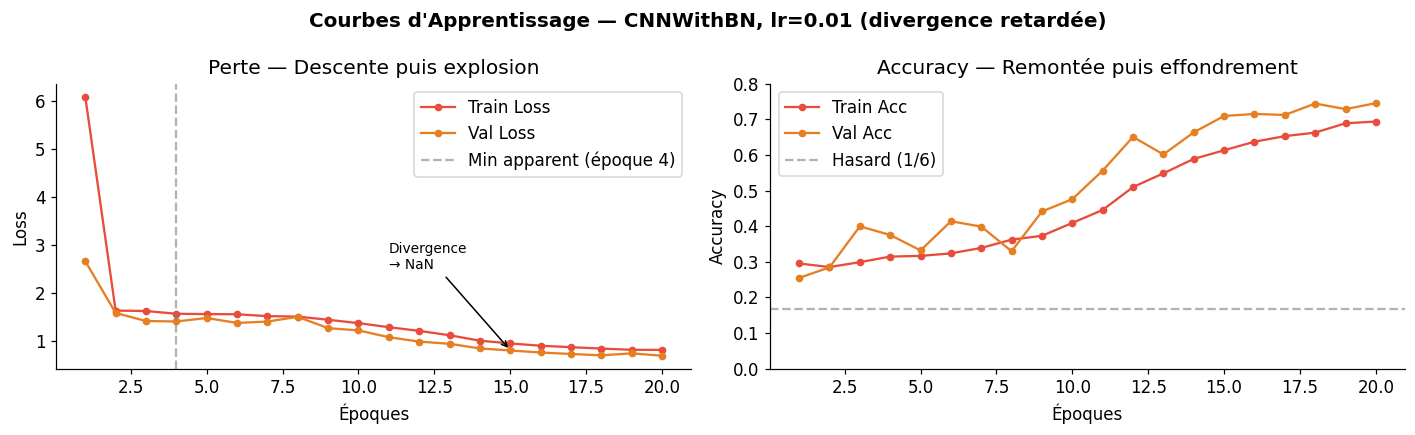

Meilleure val accuracy atteinte : 0.7452 (époque 20)
Val accuracy finale             : 0.7452


In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Courbes d\'Apprentissage — CNNWithBN, lr=0.01 (divergence retardée)', fontsize=13, fontweight='bold')

epochs_range = range(1, NUM_EPOCHS + 1)

t2_plot = [v if not (v != v) else None for v in train_losses2]
v2_plot = [v if not (v != v) else None for v in val_losses2]

ax1.plot(epochs_range, t2_plot, '-o', ms=4, color='#e74c3c', label='Train Loss')
ax1.plot(epochs_range, v2_plot, '-o', ms=4, color='#e67e22', label='Val Loss')
ax1.axvline(x=4, color='gray', linestyle='--', alpha=0.6, label='Min apparent (époque 4)')
ax1.annotate('Divergence\n→ NaN', xy=(15, 0.8), xytext=(11, 2.5),
             arrowprops=dict(arrowstyle='->', color='black'), fontsize=9)
ax1.set_title('Perte — Descente puis explosion')
ax1.set_xlabel('Époques')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(epochs_range, train_accs2, '-o', ms=4, color='#e74c3c', label='Train Acc')
ax2.plot(epochs_range, val_accs2,   '-o', ms=4, color='#e67e22', label='Val Acc')
ax2.axhline(y=1/6, color='gray', linestyle='--', alpha=0.6, label='Hasard (1/6)')
ax2.set_title('Accuracy — Remontée puis effondrement')
ax2.set_xlabel('Époques')
ax2.set_ylabel('Accuracy')
ax2.set_ylim(0, 0.8)
ax2.legend()

plt.tight_layout()
plt.show()

print(f'Meilleure val accuracy atteinte : {max(v for v in val_accs2 if v==v):.4f} (époque {val_accs2.index(max(v for v in val_accs2 if v==v))+1})')
print(f'Val accuracy finale             : {val_accs2[-1]:.4f}')


## 7 — Diagnostic et Leçons Apprises

### Résumé des deux essais

| Essai | LR | Époque NaN | Meilleure Val Acc |
|---|---|---|---|
| Essai 1 (Adam, lr=0.1) | 0.1 | Époque 6 | ~27% |
| Essai 2 (Adam, lr=0.01) | 0.01 | Époque 15 | 59.3% |

Les deux essais finissent au même endroit : **NaN, accuracy = 1/6**.
Réduire le LR retarde la divergence mais ne la prévient pas.

### Pourquoi la loss diverge-t-elle ?

**Adam n'est pas immunisé contre un LR trop élevé.**
L'optimiseur normalise les gradients par leur variance historique, mais si le LR est
trop grand, les mises à jour de poids dépassent le basin d'attraction du minimum.
Les activations explosent, BatchNorm ne peut plus normaliser des valeurs infinies,
et la perte devient `NaN` — ce qui corrompt tous les poids via la backpropagation.

**La plage standard d'Adam** pour des CNNs est `1e-3` à `3e-4`.
`lr=0.1` est 100× trop grand ; `lr=0.01` est encore 10× trop grand.

### Problèmes supplémentaires identifiés :

**1. Pas de gradient clipping**
Un `nn.utils.clip_grad_norm_` avec `max_norm=1.0` aurait pu limiter l'explosion
des gradients et retarder davantage la divergence — mais pas la corriger.

**2. Pas de détection NaN**
La boucle continue d'itérer 14 époques inutilement après la divergence.
Un `if math.isnan(t_loss): break` aurait stoppé l'entraînement dès l'époque 6.

**3. Architecture toujours sous-dimensionnée**
3 blocs suffisent pour détecter des features basiques, mais pas pour discriminer
6 classes de paysages complexes sur des images 150×150. Ce problème sera
adressé en Draft v3 avec un 4ème bloc convolutif.
